# Machine Learning Safety – Exercise Sheet 7
## Uncertainty Quantification

This exercise investigates uncertainty and confidence in machine learning models.

We will study:
- Epistemic and aleatoric uncertainty
- Model calibration and Expected Calibration Error (ECE)
- Cost-optimal decision thresholds
- Calibration of the CARLA perception models
- Temperature scaling
- The effect of confidence on safety decisions

## Exercise 7.1 – Epistemic vs. Aleatoric Uncertainty

### Epistemic Uncertainty

Epistemic uncertainty is uncertainty caused by limited knowledge of the model or insufficient training data. It can potentially be reduced by obtaining more representative training data.

### Aleatoric Uncertainty

Aleatoric uncertainty represents uncertainty that is inherent in the data and cannot be removed simply by collecting more training data.

### Questions

1. Which type is more relevant to OOD inputs, such as night images for a model trained on daytime images?
2. Which type would be expected to dominate in a correctly classified, in-distribution image?

### Answers

1. Epistemic uncertainty is more relevant to OOD inputs because the model has limited knowledge about inputs that differ from its training distribution.

2. For a correctly classified in-distribution image, aleatoric uncertainty is more relevant because the input comes from a distribution that the model has been trained to handle.

## Exercise 7.2 – Calibration and ECE

### What is Calibration?

A classifier is well-calibrated when its predicted probabilities correspond well to the actual frequency of correct predictions.

For example, among predictions made with 80% confidence, approximately 80% should be correct.

A model that consistently assigns probabilities that are too high is called overconfident. A model that assigns probabilities that are too low is underconfident.

### Expected Calibration Error (ECE)

ECE measures the difference between a model's confidence and its actual accuracy.

To compute ECE:

1. Divide predictions into confidence bins.
2. For each bin, calculate the average confidence.
3. Calculate the accuracy of predictions in that bin.
4. Compute the absolute difference between confidence and accuracy.
5. Take the weighted average of these differences across all bins.

A lower ECE indicates better calibration, while an ECE close to zero indicates that predicted confidence closely matches actual accuracy.

### Answer

A well-calibrated classifier produces confidence scores that accurately reflect the probability of being correct.

For example, if a model makes 100 predictions with approximately 80% confidence, around 80 of those predictions should be correct.

ECE measures the mismatch between confidence and accuracy across confidence bins. Therefore, a low ECE indicates good calibration, whereas a high ECE indicates that the model's confidence does not accurately reflect its prediction accuracy.

## Exercise 7.3 – Cost-Optimal Downstream Decisions

A pedestrian detector outputs:

p = P(pedestrian | x)

The autopilot chooses between two actions: braking or continuing.

The costs are:

| Action | Pedestrian Present | No Pedestrian |
|---|---:|---:|
| Brake | 0 | CFP = 1 |
| Continue | CFN = 100 | 0 |

We derive the expected loss of each action and determine the cost-optimal probability threshold.

In [1]:
# Exercise 7.3 – Cost-optimal threshold

CFN = 100
CFP = 1

# Expected loss
# Brake: false positive can happen when there is no pedestrian
# Continue: false negative can happen when there is a pedestrian

# E[L | brake] = CFP * (1 - p)
# E[L | continue] = CFN * p

# Find threshold where both losses are equal:
# CFP * (1 - p) = CFN * p

tau_star = CFP / (CFN + CFP)

print(f"CFN = {CFN}")
print(f"CFP = {CFP}")
print(f"Optimal threshold τ* = {tau_star:.4f}")
print(f"Optimal threshold ≈ {tau_star * 100:.2f}%")

CFN = 100
CFP = 1
Optimal threshold τ* = 0.0099
Optimal threshold ≈ 0.99%


### Interpretation

The cost-optimal threshold is τ* ≈ 0.0099 (about 0.99%).

Therefore, the autopilot should brake when the predicted probability of a pedestrian is greater than approximately 1%.

This threshold is much lower than the standard 0.5 threshold because a false negative has a much higher cost (100) than a false positive (1).

The threshold is only optimal when the predicted probabilities are well-calibrated. If the model is overconfident or poorly calibrated, the probability may not accurately represent the true likelihood of a pedestrian being present.

# Practical: Calibrating the CARLA Model

## Exercise 7.4 – Measuring Calibration

We evaluate the confidence calibration of the three trained CARLA perception models on the in-distribution test set.

For each model, we will:
- obtain predictions and confidence scores,
- compute the Expected Calibration Error (ECE),
- and visualize calibration using a reliability diagram.

In [2]:
# Exercise 7.4 – Fresh notebook setup

from google.colab import drive
import os

drive.mount('/content/drive')

print("Google Drive mounted successfully.")

# Show the main folders in MyDrive
print("\nFolders/files in MyDrive:")
for item in os.listdir('/content/drive/MyDrive'):
    print(item)

Mounted at /content/drive
Google Drive mounted successfully.

Folders/files in MyDrive:
010_intro.pdf
Colab Notebooks
ML_Safety
VoicenoteKFC


In [3]:
# Inspect the ML_Safety folder

ml_safety_path = '/content/drive/MyDrive/ML_Safety'

print("Files and folders inside ML_Safety:\n")

for item in os.listdir(ml_safety_path):
    full_path = os.path.join(ml_safety_path, item)

    if os.path.isdir(full_path):
        print(f"[FOLDER] {item}")
    else:
        print(f"[FILE]   {item}")

Files and folders inside ML_Safety:

[FILE]   test.zip
[FILE]   test-fog.zip
[FILE]   test-night.zip
[FILE]   test-town-01.zip
[FILE]   validation.zip
[FILE]   train.zip
[FILE]   traffic_light_model.pth
[FILE]   pedestrian_model.pth
[FILE]   vehicle_model.pth


In [4]:
# Inspect the three trained model checkpoints

import torch
import os

model_files = {
    "Pedestrian": os.path.join(ml_safety_path, "pedestrian_model.pth"),
    "Vehicle": os.path.join(ml_safety_path, "vehicle_model.pth"),
    "Traffic Light": os.path.join(ml_safety_path, "traffic_light_model.pth")
}

for name, path in model_files.items():
    checkpoint = torch.load(path, map_location='cpu')

    print("\n" + "=" * 60)
    print(f"{name} model")
    print("=" * 60)
    print("File:", path)
    print("Object type:", type(checkpoint))

    if isinstance(checkpoint, dict):
        print("Checkpoint keys:", list(checkpoint.keys()))

        # Show parameter shapes if this is a state dictionary
        for key, value in checkpoint.items():
            if hasattr(value, "shape"):
                print(f"{key}: {tuple(value.shape)}")


Pedestrian model
File: /content/drive/MyDrive/ML_Safety/pedestrian_model.pth
Object type: <class 'collections.OrderedDict'>
Checkpoint keys: ['model.0.weight', 'model.0.bias', 'model.3.weight', 'model.3.bias', 'model.6.weight', 'model.6.bias', 'model.10.weight', 'model.10.bias', 'model.12.weight', 'model.12.bias']
model.0.weight: (16, 3, 3, 3)
model.0.bias: (16,)
model.3.weight: (32, 16, 3, 3)
model.3.bias: (32,)
model.6.weight: (64, 32, 3, 3)
model.6.bias: (64,)
model.10.weight: (128, 50176)
model.10.bias: (128,)
model.12.weight: (1, 128)
model.12.bias: (1,)

Vehicle model
File: /content/drive/MyDrive/ML_Safety/vehicle_model.pth
Object type: <class 'collections.OrderedDict'>
Checkpoint keys: ['model.0.weight', 'model.0.bias', 'model.3.weight', 'model.3.bias', 'model.6.weight', 'model.6.bias', 'model.10.weight', 'model.10.bias', 'model.12.weight', 'model.12.bias']
model.0.weight: (16, 3, 3, 3)
model.0.bias: (16,)
model.3.weight: (32, 16, 3, 3)
model.3.bias: (32,)
model.6.weight: (64, 

In [5]:
import os
import zipfile
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader

In [6]:
BASE_PATH = "/content/drive/MyDrive/ML_Safety"

PED_MODEL_PATH = os.path.join(BASE_PATH, "pedestrian_model.pth")
VEH_MODEL_PATH = os.path.join(BASE_PATH, "vehicle_model.pth")
TL_MODEL_PATH = os.path.join(BASE_PATH, "traffic_light_model.pth")

TEST_ZIP = os.path.join(BASE_PATH, "test.zip")
VAL_ZIP = os.path.join(BASE_PATH, "validation.zip")

print("Pedestrian model:", PED_MODEL_PATH)
print("Vehicle model:", VEH_MODEL_PATH)
print("Traffic-light model:", TL_MODEL_PATH)

Pedestrian model: /content/drive/MyDrive/ML_Safety/pedestrian_model.pth
Vehicle model: /content/drive/MyDrive/ML_Safety/vehicle_model.pth
Traffic-light model: /content/drive/MyDrive/ML_Safety/traffic_light_model.pth


In [7]:
class PedestrianClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(50176, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pedestrian_model = PedestrianClassifier().to(device)
vehicle_model = PedestrianClassifier().to(device)
traffic_light_model = PedestrianClassifier().to(device)

pedestrian_model.load_state_dict(torch.load(
    PED_MODEL_PATH,
    map_location=device
))

vehicle_model.load_state_dict(torch.load(
    VEH_MODEL_PATH,
    map_location=device
))

traffic_light_model.load_state_dict(torch.load(
    TL_MODEL_PATH,
    map_location=device
))

pedestrian_model.eval()
vehicle_model.eval()
traffic_light_model.eval()

print("All three models loaded successfully.")
print("Device:", device)

All three models loaded successfully.
Device: cuda


In [9]:
import zipfile

with zipfile.ZipFile(TEST_ZIP, "r") as z:
    files = z.namelist()

print("Number of files:", len(files))
print("\nFirst 30 files:")
for f in files[:30]:
    print(f)

Number of files: 7216

First 30 files:
test/
test/rgb-front/
test/rgb-front/029290.jpg
test/rgb-front/001460.jpg
test/rgb-front/024450.jpg
test/rgb-front/027230.jpg
test/rgb-front/010670.jpg
test/rgb-front/021730.jpg
test/rgb-front/029560.jpg
test/rgb-front/009930.jpg
test/rgb-front/020520.jpg
test/rgb-front/002240.jpg
test/rgb-front/007690.jpg
test/rgb-front/022250.jpg
test/rgb-front/018690.jpg
test/rgb-front/014760.jpg
test/rgb-front/015340.jpg
test/rgb-front/015010.jpg
test/rgb-front/005330.jpg
test/rgb-front/015500.jpg
test/rgb-front/011930.jpg
test/rgb-front/016270.jpg
test/rgb-front/024520.jpg
test/rgb-front/031220.jpg
test/rgb-front/022490.jpg
test/rgb-front/023920.jpg
test/rgb-front/013420.jpg
test/rgb-front/008450.jpg
test/rgb-front/019610.jpg
test/rgb-front/030300.jpg


In [10]:
with zipfile.ZipFile(TEST_ZIP, "r") as z:
    files = z.namelist()

non_images = [
    f for f in files
    if not f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Non-image files:")
for f in non_images:
    print(f)

Non-image files:
test/
test/rgb-front/
test/sim.log
test/imu.feather
test/segmentation-front/
test/carla.log
test/labels.csv
test/.hydra/
test/.hydra/overrides.yaml
test/.hydra/config.yaml
test/.hydra/hydra.yaml
test/actions.feather
test/labels.feather
test/gnss.feather
test/weather.feather
test/collisions.feather


In [11]:
import pandas as pd

with zipfile.ZipFile(TEST_ZIP, "r") as z:
    with z.open("test/labels.csv") as f:
        labels_df = pd.read_csv(f)

print("Shape:", labels_df.shape)
print("\nColumns:")
print(labels_df.columns.tolist())

print("\nFirst 5 rows:")
display(labels_df.head())

Shape: (3600, 7)

Columns:
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

First 5 rows:


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


In [12]:
TEST_DIR = "/content/test"

with zipfile.ZipFile(TEST_ZIP, "r") as z:
    z.extractall("/content")

print("Test data extracted.")
print("Number of images:", len(os.listdir("/content/test/rgb-front")))

Test data extracted.
Number of images: 3600


In [13]:
def load_image(path):
    image = Image.open(path).convert("RGB")
    image = image.resize((224, 224))

    image = np.array(image, dtype=np.float32) / 255.0
    image = np.transpose(image, (2, 0, 1))

    return torch.tensor(image, dtype=torch.float32)

In [14]:
def get_predictions(model, frames):
    probabilities = []

    model.eval()

    with torch.no_grad():
        for frame in frames:
            image_path = f"/content/test/rgb-front/{frame:06d}.jpg"

            image = load_image(image_path)
            image = image.unsqueeze(0).to(device)

            output = model(image)
            probability = torch.sigmoid(output).item()

            probabilities.append(probability)

    return np.array(probabilities)

In [15]:
frames = labels_df["frame"].values

pedestrian_probabilities = get_predictions(
    pedestrian_model,
    frames
)

vehicle_probabilities = get_predictions(
    vehicle_model,
    frames
)

traffic_light_probabilities = get_predictions(
    traffic_light_model,
    frames
)

print("Predictions completed.")
print("Pedestrian:", len(pedestrian_probabilities))
print("Vehicle:", len(vehicle_probabilities))
print("Traffic light:", len(traffic_light_probabilities))

Predictions completed.
Pedestrian: 3600
Vehicle: 3600
Traffic light: 3600


In [16]:
def calculate_ece(probabilities, labels, n_bins=10):
    probabilities = np.asarray(probabilities)
    labels = np.asarray(labels).astype(int)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (
                (probabilities >= bin_edges[i]) &
                (probabilities <= bin_edges[i + 1])
            )
        else:
            mask = (
                (probabilities >= bin_edges[i]) &
                (probabilities < bin_edges[i + 1])
            )

        if np.sum(mask) == 0:
            continue

        confidence = probabilities[mask].mean()
        accuracy = labels[mask].mean()

        ece += (
            np.sum(mask) / len(labels)
        ) * abs(accuracy - confidence)

    return ece

In [17]:
pedestrian_labels = labels_df["has_pedestrian"].astype(int).values
vehicle_labels = labels_df["has_vehicle"].astype(int).values
traffic_light_labels = labels_df["has_traffic_light"].astype(int).values

pedestrian_ece = calculate_ece(
    pedestrian_probabilities,
    pedestrian_labels
)

vehicle_ece = calculate_ece(
    vehicle_probabilities,
    vehicle_labels
)

traffic_light_ece = calculate_ece(
    traffic_light_probabilities,
    traffic_light_labels
)

print("ECE Results")
print("=" * 40)
print(f"Pedestrian    ECE: {pedestrian_ece:.4f}")
print(f"Vehicle       ECE: {vehicle_ece:.4f}")
print(f"Traffic Light ECE: {traffic_light_ece:.4f}")

ECE Results
Pedestrian    ECE: 0.0820
Vehicle       ECE: 0.0718
Traffic Light ECE: 0.0496


## Exercise 7.4.2 — Reliability Diagrams

A reliability diagram compares the model's predicted confidence with its actual accuracy.

A perfectly calibrated model would lie close to the diagonal line.

The confidence values are divided into bins. For each bin, we calculate the mean confidence and the fraction of correct predictions.

In [18]:
def reliability_data(probabilities, labels, n_bins=10):
    probabilities = np.asarray(probabilities)
    labels = np.asarray(labels).astype(int)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    bin_confidence = []
    bin_accuracy = []

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (
                (probabilities >= bin_edges[i]) &
                (probabilities <= bin_edges[i + 1])
            )
        else:
            mask = (
                (probabilities >= bin_edges[i]) &
                (probabilities < bin_edges[i + 1])
            )

        if np.sum(mask) == 0:
            continue

        bin_confidence.append(probabilities[mask].mean())
        bin_accuracy.append(labels[mask].mean())

    return np.array(bin_confidence), np.array(bin_accuracy)

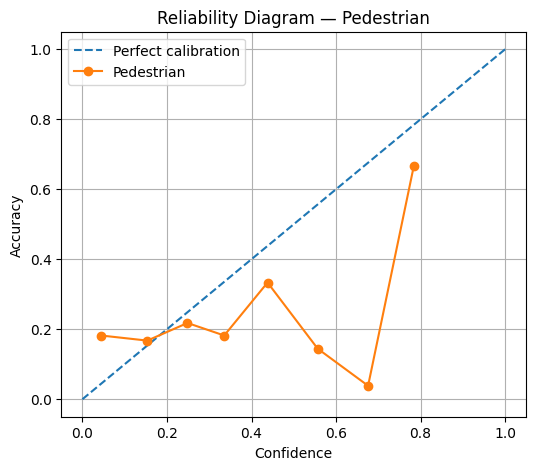

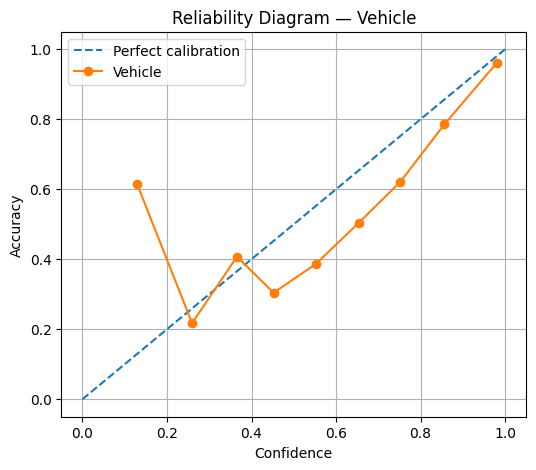

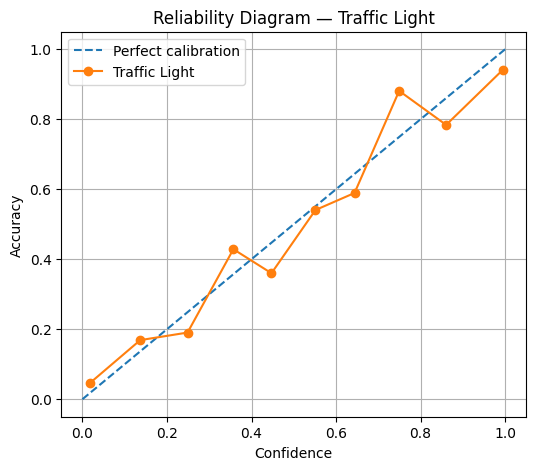

In [19]:
models_for_plot = [
    ("Pedestrian", pedestrian_probabilities, pedestrian_labels),
    ("Vehicle", vehicle_probabilities, vehicle_labels),
    ("Traffic Light", traffic_light_probabilities, traffic_light_labels)
]

for name, probabilities, labels in models_for_plot:

    confidence, accuracy = reliability_data(
        probabilities,
        labels,
        n_bins=10
    )

    plt.figure(figsize=(6, 5))

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    plt.plot(
        confidence,
        accuracy,
        marker="o",
        label=name
    )

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Reliability Diagram — {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

## Exercise 7.4.3 — Calibration Interpretation

The reliability diagrams show that the three models have different calibration behaviour.

- **Pedestrian model:** The reliability curve is mostly below the diagonal, especially at higher confidence values. This indicates that the model is generally **overconfident**: its predicted confidence is higher than its actual accuracy.

- **Vehicle model:** The curve is mixed, with some bins above and some below the diagonal. However, at higher confidence levels the curve is mostly below the diagonal, indicating **overconfidence** in these regions.

- **Traffic-light model:** The curve is generally closer to the diagonal than the other two models, although some bins lie above or below it. Therefore, it is **better calibrated overall**, with smaller calibration errors.

The pattern is therefore **not completely consistent across all three models**. The pedestrian and vehicle models show stronger signs of overconfidence, while the traffic-light model is comparatively better calibrated.

This is also consistent with the ECE values:
- Pedestrian: ECE = 0.0820
- Vehicle: ECE = 0.0718
- Traffic Light: ECE = 0.0496

The traffic-light model has the lowest ECE and is therefore the best calibrated of the three models.

## Exercise 7.5 — Temperature Scaling

Temperature scaling adjusts the model's logits using a temperature parameter T:

p(y | x) = softmax(f(x) / T)

The temperature T is optimized on the validation set using negative log-likelihood (NLL).

- T > 1 makes predictions less confident.
- T < 1 makes predictions more confident.
- T = 1 leaves the original probabilities unchanged.

We will find the optimal T separately for the pedestrian, vehicle, and traffic-light models.

In [20]:
import zipfile
import os

VAL_ZIP = "/content/drive/MyDrive/ML_Safety/validation.zip"

with zipfile.ZipFile(VAL_ZIP, "r") as z:
    files = z.namelist()

print("Number of files:", len(files))
print("\nFirst 30 files:")
for f in files[:30]:
    print(f)

print("\nCSV / label files:")
for f in files:
    if f.endswith(".csv") or f.endswith(".feather"):
        print(f)

Number of files: 7216

First 30 files:
validation/
validation/.hydra/
validation/.hydra/config.yaml
validation/.hydra/hydra.yaml
validation/.hydra/overrides.yaml
validation/actions.feather
validation/carla.log
validation/collisions.feather
validation/gnss.feather
validation/imu.feather
validation/labels.csv
validation/labels.feather
validation/rgb-front/
validation/rgb-front/000000.jpg
validation/rgb-front/000010.jpg
validation/rgb-front/000020.jpg
validation/rgb-front/000030.jpg
validation/rgb-front/000040.jpg
validation/rgb-front/000050.jpg
validation/rgb-front/000060.jpg
validation/rgb-front/000070.jpg
validation/rgb-front/000080.jpg
validation/rgb-front/000090.jpg
validation/rgb-front/000100.jpg
validation/rgb-front/000110.jpg
validation/rgb-front/000120.jpg
validation/rgb-front/000130.jpg
validation/rgb-front/000140.jpg
validation/rgb-front/000150.jpg
validation/rgb-front/000160.jpg

CSV / label files:
validation/actions.feather
validation/collisions.feather
validation/gnss.feathe

In [21]:
import zipfile
import pandas as pd
import os

VAL_ZIP = "/content/drive/MyDrive/ML_Safety/validation.zip"

# Extract validation data
VAL_DIR = "/content/validation"

if not os.path.exists(VAL_DIR):
    with zipfile.ZipFile(VAL_ZIP, "r") as z:
        z.extractall("/content")

# Read validation labels
val_labels_df = pd.read_csv("/content/validation/labels.csv")

print("Validation labels shape:", val_labels_df.shape)
print("\nColumns:")
print(val_labels_df.columns.tolist())

print("\nFirst 5 rows:")
display(val_labels_df.head())

print("\nData types:")
print(val_labels_df.dtypes)

Validation labels shape: (3600, 7)

Columns:
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

First 5 rows:


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,True,False,0,178,10
1,10,True,False,False,347,0,2
2,20,True,False,False,347,0,0
3,30,True,False,False,347,0,0
4,40,True,False,False,347,0,0



Data types:
frame                int64
has_traffic_light     bool
has_pedestrian        bool
has_vehicle           bool
px_traffic_light     int64
px_pedestrian        int64
px_vehicle           int64
dtype: object


In [22]:
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

# Image preprocessing
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

val_image_dir = "/content/validation/rgb-front"

# Make sure models are in evaluation mode
pedestrian_model.eval()
vehicle_model.eval()
traffic_light_model.eval()

# Store validation logits
pedestrian_val_logits = []
vehicle_val_logits = []
traffic_light_val_logits = []

pedestrian_val_labels = []
vehicle_val_labels = []
traffic_light_val_labels = []

for _, row in tqdm(
    val_labels_df.iterrows(),
    total=len(val_labels_df),
    desc="Processing validation images"
):
    frame = int(row["frame"])

    image_path = os.path.join(
        val_image_dir,
        f"{frame:06d}.jpg"
    )

    image = Image.open(image_path).convert("RGB")
    image_tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        ped_logit = pedestrian_model(image_tensor)
        veh_logit = vehicle_model(image_tensor)
        tl_logit = traffic_light_model(image_tensor)

    pedestrian_val_logits.append(float(ped_logit.squeeze().cpu()))
    vehicle_val_logits.append(float(veh_logit.squeeze().cpu()))
    traffic_light_val_logits.append(float(tl_logit.squeeze().cpu()))

    pedestrian_val_labels.append(int(row["has_pedestrian"]))
    vehicle_val_labels.append(int(row["has_vehicle"]))
    traffic_light_val_labels.append(int(row["has_traffic_light"]))

# Convert to numpy arrays
pedestrian_val_logits = np.array(pedestrian_val_logits)
vehicle_val_logits = np.array(vehicle_val_logits)
traffic_light_val_logits = np.array(traffic_light_val_logits)

pedestrian_val_labels = np.array(pedestrian_val_labels)
vehicle_val_labels = np.array(vehicle_val_labels)
traffic_light_val_labels = np.array(traffic_light_val_labels)

print("Validation logits collected successfully.")
print("Number of samples:", len(pedestrian_val_logits))

print("\nShapes:")
print("Pedestrian:", pedestrian_val_logits.shape)
print("Vehicle:", vehicle_val_logits.shape)
print("Traffic Light:", traffic_light_val_logits.shape)

Processing validation images:   0%|          | 0/3600 [00:00<?, ?it/s]

Validation logits collected successfully.
Number of samples: 3600

Shapes:
Pedestrian: (3600,)
Vehicle: (3600,)
Traffic Light: (3600,)


In [23]:
import torch
import torch.nn.functional as F
import numpy as np

def find_optimal_temperature(logits, labels):
    logits = torch.tensor(logits, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    temperatures = np.arange(0.5, 3.01, 0.1)

    best_temperature = None
    best_nll = float("inf")

    for T in temperatures:
        scaled_logits = logits / T

        loss = F.binary_cross_entropy_with_logits(
            scaled_logits,
            labels
        )

        nll = float(loss.item())

        if nll < best_nll:
            best_nll = nll
            best_temperature = T

    return best_temperature, best_nll


# Find optimal temperature for each model
pedestrian_T, pedestrian_nll = find_optimal_temperature(
    pedestrian_val_logits,
    pedestrian_val_labels
)

vehicle_T, vehicle_nll = find_optimal_temperature(
    vehicle_val_logits,
    vehicle_val_labels
)

traffic_light_T, traffic_light_nll = find_optimal_temperature(
    traffic_light_val_logits,
    traffic_light_val_labels
)


print("=" * 50)
print("Optimal Temperature Scaling Results")
print("=" * 50)

print(f"Pedestrian    T = {pedestrian_T:.1f} | NLL = {pedestrian_nll:.4f}")
print(f"Vehicle       T = {vehicle_T:.1f} | NLL = {vehicle_nll:.4f}")
print(f"Traffic Light T = {traffic_light_T:.1f} | NLL = {traffic_light_nll:.4f}")

Optimal Temperature Scaling Results
Pedestrian    T = 2.3 | NLL = 0.6061
Vehicle       T = 1.6 | NLL = 0.4479
Traffic Light T = 1.1 | NLL = 0.1081


## Exercise 7.5 — Temperature Scaling: ECE Before and After

Temperature scaling was applied to the three CARLA models using the validation set.
The optimal temperatures were selected by minimizing the negative log-likelihood (NLL).

We now evaluate the effect of temperature scaling on the in-distribution test set
by comparing the Expected Calibration Error (ECE) before and after calibration.

In [25]:
# ============================================================
# TEST-SET ECE BEFORE AND AFTER TEMPERATURE SCALING
# ============================================================

def probability_to_logit(probabilities):
    probabilities = np.asarray(probabilities)

    # Avoid log(0) and log(infinity)
    probabilities = np.clip(probabilities, 1e-7, 1 - 1e-7)

    return np.log(probabilities / (1 - probabilities))


def apply_temperature(probabilities, temperature):
    logits = probability_to_logit(probabilities)
    scaled_logits = logits / temperature

    return 1 / (1 + np.exp(-scaled_logits))


# Test labels
test_ped_labels = labels_df["has_pedestrian"].astype(int).values
test_veh_labels = labels_df["has_vehicle"].astype(int).values
test_tl_labels = labels_df["has_traffic_light"].astype(int).values


# Original test probabilities
ped_before = np.asarray(pedestrian_probabilities)
veh_before = np.asarray(vehicle_probabilities)
tl_before = np.asarray(traffic_light_probabilities)


# Apply learned temperatures
ped_after = apply_temperature(
    ped_before,
    pedestrian_T
)

veh_after = apply_temperature(
    veh_before,
    vehicle_T
)

tl_after = apply_temperature(
    tl_before,
    traffic_light_T
)


# Calculate ECE before and after
ped_ece_before = calculate_ece(
    ped_before,
    test_ped_labels
)

ped_ece_after = calculate_ece(
    ped_after,
    test_ped_labels
)


veh_ece_before = calculate_ece(
    veh_before,
    test_veh_labels
)

veh_ece_after = calculate_ece(
    veh_after,
    test_veh_labels
)


tl_ece_before = calculate_ece(
    tl_before,
    test_tl_labels
)

tl_ece_after = calculate_ece(
    tl_after,
    test_tl_labels
)


print("=" * 60)
print("ECE BEFORE AND AFTER TEMPERATURE SCALING")
print("=" * 60)

print(
    f"Pedestrian    : "
    f"{ped_ece_before:.4f} → {ped_ece_after:.4f}"
)

print(
    f"Vehicle       : "
    f"{veh_ece_before:.4f} → {veh_ece_after:.4f}"
)

print(
    f"Traffic Light : "
    f"{tl_ece_before:.4f} → {tl_ece_after:.4f}"
)

ECE BEFORE AND AFTER TEMPERATURE SCALING
Pedestrian    : 0.0820 → 0.1509
Vehicle       : 0.0718 → 0.0504
Traffic Light : 0.0496 → 0.0468


## Exercise 7.5.2 — Effect of Temperature Scaling

Temperature scaling improved the calibration of the vehicle and traffic-light models.

- The vehicle model ECE decreased from 0.0718 to 0.0504.
- The traffic-light model ECE decreased from 0.0496 to 0.0468.
- The pedestrian model ECE increased from 0.0820 to 0.1509, indicating worse calibration after scaling.

Therefore, temperature scaling does not consistently improve calibration for all three models. Its effect depends on the individual model and its learned temperature.

## Exercise 7.6 — Cost-Optimal Decision in Practice

The pedestrian classifier is evaluated using the cost function

\[
\mathcal{L} = C_{FN}\cdot \#FN + C_{FP}\cdot \#FP
\]

with \(C_{FN}=100\) and \(C_{FP}=1\).

The standard decision threshold is \(\tau=0.5\), while the cost-optimal threshold from Exercise 7.3 is approximately \(\tau^*=0.0099\).

We compare the uncalibrated and temperature-scaled pedestrian models at both thresholds.

In [26]:
# ============================================================
# Exercise 7.6 — Cost-Optimal Decision in Practice
# ============================================================

CFN = 100
CFP = 1
TAU_STANDARD = 0.5
TAU_OPTIMAL = 0.0099

# Pedestrian ground-truth labels
pedestrian_labels = labels_df["has_pedestrian"].astype(int).values

# Uncalibrated pedestrian probabilities
pedestrian_prob_uncalibrated = np.asarray(
    pedestrian_probabilities
)

# Temperature-scaled pedestrian probabilities
pedestrian_prob_calibrated = apply_temperature(
    pedestrian_prob_uncalibrated,
    pedestrian_T
)

print("Pedestrian test samples:", len(pedestrian_labels))
print("Temperature:", pedestrian_T)
print("Standard threshold:", TAU_STANDARD)
print("Cost-optimal threshold:", TAU_OPTIMAL)

Pedestrian test samples: 3600
Temperature: 2.3
Standard threshold: 0.5
Cost-optimal threshold: 0.0099


In [27]:
def calculate_cost(probabilities, labels, threshold, CFN=100, CFP=1):
    predictions = (probabilities >= threshold).astype(int)

    # False negatives: true pedestrian, predicted no pedestrian
    FN = np.sum((labels == 1) & (predictions == 0))

    # False positives: no pedestrian, predicted pedestrian
    FP = np.sum((labels == 0) & (predictions == 1))

    total_loss = CFN * FN + CFP * FP

    return FN, FP, total_loss


# ------------------------------------------------------------
# 1. Uncalibrated model
# ------------------------------------------------------------

uncalibrated_05 = calculate_cost(
    pedestrian_prob_uncalibrated,
    pedestrian_labels,
    TAU_STANDARD,
    CFN,
    CFP
)

uncalibrated_optimal = calculate_cost(
    pedestrian_prob_uncalibrated,
    pedestrian_labels,
    TAU_OPTIMAL,
    CFN,
    CFP
)


# ------------------------------------------------------------
# 2. Temperature-scaled model
# ------------------------------------------------------------

calibrated_05 = calculate_cost(
    pedestrian_prob_calibrated,
    pedestrian_labels,
    TAU_STANDARD,
    CFN,
    CFP
)

calibrated_optimal = calculate_cost(
    pedestrian_prob_calibrated,
    pedestrian_labels,
    TAU_OPTIMAL,
    CFN,
    CFP
)


print("=" * 65)
print("Exercise 7.6 — Cost Results")
print("=" * 65)

print("\nUncalibrated model")
print(f"τ = 0.5    → FN = {uncalibrated_05[0]}, "
      f"FP = {uncalibrated_05[1]}, "
      f"Loss = {uncalibrated_05[2]}")

print(f"τ = 0.0099 → FN = {uncalibrated_optimal[0]}, "
      f"FP = {uncalibrated_optimal[1]}, "
      f"Loss = {uncalibrated_optimal[2]}")


print("\nTemperature-scaled model")
print(f"τ = 0.5    → FN = {calibrated_05[0]}, "
      f"FP = {calibrated_05[1]}, "
      f"Loss = {calibrated_05[2]}")

print(f"τ = 0.0099 → FN = {calibrated_optimal[0]}, "
      f"FP = {calibrated_optimal[1]}, "
      f"Loss = {calibrated_optimal[2]}")

Exercise 7.6 — Cost Results

Uncalibrated model
τ = 0.5    → FN = 673, FP = 117, Loss = 67417
τ = 0.0099 → FN = 24, FP = 2756, Loss = 5156

Temperature-scaled model
τ = 0.5    → FN = 673, FP = 117, Loss = 67417
τ = 0.0099 → FN = 0, FP = 2884, Loss = 2884


## Exercise 7.6.3 — Cost Comparison

| Model | τ = 0.5 | τ = 0.0099 |
|---|---:|---:|
| Uncalibrated | 67,417 | 5,156 |
| Temperature-scaled | 67,417 | **2,884** |

The lowest total loss is obtained with the **temperature-scaled model at the cost-optimal threshold τ = 0.0099**.

## Exercise 7.6 — Interpretation

Using the standard threshold of τ = 0.5 results in a high number of false negatives because false negatives are very costly (\(C_{FN}=100\)).

Lowering the threshold to the cost-optimal value τ = 0.0099 greatly reduces false negatives and therefore substantially reduces the total loss.

For the uncalibrated model, the loss decreases from 67,417 to 5,156.

For the temperature-scaled model, the loss decreases from 67,417 to 2,884. The temperature-scaled model at τ = 0.0099 therefore achieves the lowest total loss.

This demonstrates why cost-sensitive decision thresholds are important when the costs of false negatives and false positives are highly asymmetric.

## Exercise 7.7.1 — Causal Scenario

### Causal chain

A pedestrian is present in the scene, but the pedestrian classifier produces a false negative with high confidence. Because the model is overconfident, the planner interprets the perception output as reliable and does not trigger the low-confidence fallback.

The resulting causal chain is:

**Pedestrian present**
→ **False-negative pedestrian detection**
→ **High-confidence prediction of "no pedestrian"**
→ **Planner treats the perception output as reliable**
→ **Low-confidence fallback is not triggered**
→ **Planner does not command braking**
→ **Vehicle fails to brake for the pedestrian**

The new causal scenario is therefore that **an overconfident but incorrect pedestrian perception output prevents the safety fallback from being activated, allowing an unsafe control action to occur.**

This connects the calibration problem directly to the existing hazard and unsafe control action.

## Exercise 7.7.2 — Safety Constraints

### Model-level constraint

The pedestrian perception model shall maintain acceptable calibration so that its confidence scores are sufficiently reliable for downstream safety decisions.

In particular, the model shall be evaluated using ECE, and calibration shall be monitored before the confidence score is used to determine whether a safety fallback is required.

For the pedestrian model, the measured ECE was:

- Before temperature scaling: **0.0820**
- After temperature scaling: **0.1509**

Therefore, temperature scaling did not improve the pedestrian model's ECE on the test set, and the calibrated model should not automatically be assumed to be safer.

### System-level constraint

The planner shall not rely on a high-confidence pedestrian classification alone to suppress safety actions.

If the pedestrian perception output is unreliable, unavailable, or outside the validated operating conditions, the planner shall trigger an appropriate safety fallback rather than continuing normal operation solely based on the perception output.

The system should also use the cost-sensitive pedestrian threshold derived in Exercise 7.6 (\(\tau^* = 0.0099\)) rather than automatically relying on the standard threshold of 0.5, because false negatives have a much higher cost than false positives.

## Exercise 7.7.3 — Verification

The model-level calibration constraint can be verified using the ECE measurements obtained in Exercises 7.4 and 7.5.

The measured pedestrian ECE was:

- Uncalibrated: **0.0820**
- Temperature-scaled: **0.1509**

Thus, temperature scaling did not improve the pedestrian model's calibration on the test set. Instead, its ECE increased from 0.0820 to 0.1509.

Because no numerical maximum ECE threshold was specified in the exercise, it cannot be concluded from the given results that the model formally satisfies a particular ECE requirement.

The results do, however, provide evidence that calibration must be explicitly evaluated rather than assuming that temperature scaling automatically makes the model safer.

## Exercise 7.7.4 — Residual Risk

Even a perfectly calibrated model does not eliminate the underlying safety risk.

Calibration only means that predicted confidence corresponds appropriately to observed accuracy. It does not guarantee that every individual prediction is correct.

A perfectly calibrated model can still produce false-negative pedestrian detections. Therefore, the unsafe control action and the resulting hazard can still occur.

In addition, calibration does not by itself guarantee robustness to changes in the environment, distribution shifts, sensor problems, or other perception failures.

Therefore, calibration alone does not completely close the safety scenario. A system-level safety fallback is still required to reduce the residual risk when perception is unreliable.